<a href="https://colab.research.google.com/github/diyayourfav/AI-MLModule/blob/main/DiyaBudhathoki_Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install/import libraries

In [ ]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

# Unzip the dataset

In [4]:
zip_path = "/content/drive/MyDrive/Ai_Ml/Data/Week5/FruitinAmazon.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Corrected base_dir to point to the extracted content
base_dir = "/content/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: /content/FruitinAmazon/train
Test path: /content/FruitinAmazon/test


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task 1: Data understanding and visualization

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


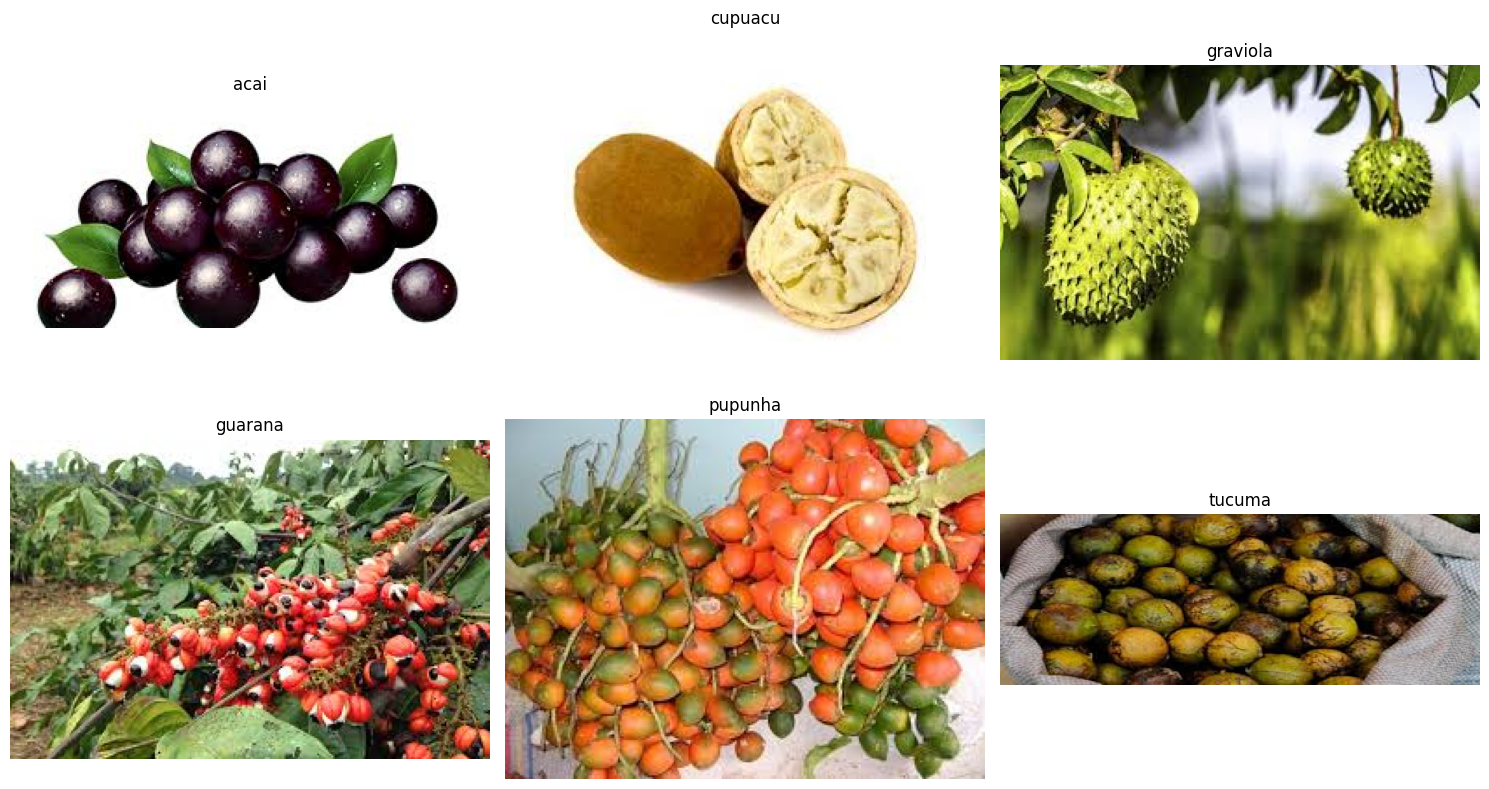

In [5]:
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_names)

sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    chosen = random.choice(images)
    sample_images.append((class_name, os.path.join(class_path, chosen)))

plt.figure(figsize=(15, 8))

for i, (class_name, img_path) in enumerate(sample_images):
    plt.subplot(2, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 1: Check corrupted images

In [6]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


# Task 2: Load and preprocess image data

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

--- Verifying raw dataset batch before rescaling ---
  Image batch shape: (16, 128, 128, 3)
  Label batch shape: (16,)
  Image data type: <dtype: 'float32'>
  Image pixel value range (example first image): 0.0579071044921875 - 255.0
  First 5 labels in batch: [1 0 5 4 4]


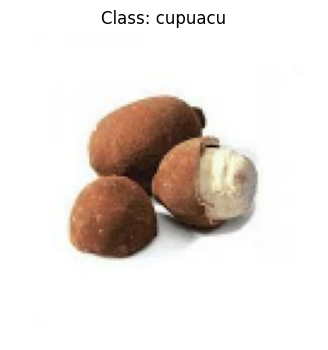

--- End raw dataset verification ---

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [7]:
img_height = 128
img_width = 128
batch_size = 16   # use 16 because training requirement later says batch size 16
validation_split = 0.2
seed = 123

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names

# --- Verification before mapping ---
print("\n--- Verifying raw dataset batch before rescaling ---")
for image_batch, labels_batch in train_ds.take(1):
    print(f"  Image batch shape: {image_batch.shape}")
    print(f"  Label batch shape: {labels_batch.shape}")
    print(f"  Image data type: {image_batch.dtype}")
    print(f"  Image pixel value range (example first image): {image_batch[0].numpy().min()} - {image_batch[0].numpy().max()}")
    print(f"  First 5 labels in batch: {labels_batch.numpy()[:5]}")

    # Display one image to verify (should be 0-255)
    plt.figure(figsize=(4, 4))
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(f"Class: {class_names[labels_batch[0].numpy()]}")
    plt.axis("off")
    plt.show()
print("--- End raw dataset verification ---\n")
# --- End Verification before mapping ---

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Task 3: Build the CNN model

In [9]:
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the model

In [11]:
checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.1187 - loss: 1.8808
Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 242ms/step - accuracy: 0.1250 - loss: 1.8976 - val_accuracy: 0.2222 - val_loss: 1.7274
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.2677 - loss: 1.7539
Epoch 2: val_accuracy did not improve from 0.22222
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.2500 - loss: 1.7176 - val_accuracy: 0.1667 - val_loss: 1.8013
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.5229 - loss: 1.5100
Epoch 3: val_accuracy did not improve from 0.22222
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.5000 - loss: 1.4770 - val_accuracy: 0.1111 - val_loss: 1.6969
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7410 - loss: 1.1054
Epoch 4: val_accuracy improved from 0.22222 to 0.50000, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.6944 - loss: 1.0889 - val_accuracy: 0.5000 - val_loss: 1.2637
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7809 - loss: 0.7499
Epoch 5: val_accuracy improved from 0.50000 to 0.72222, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.7639 - loss: 0.7382 - val_accuracy: 0.7222 - val_loss: 1.0481
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8288 - loss: 0.6187
Epoch 6: val_accuracy improved from 0.72222 to 0.88889, saving model to best_fruit_model.h5



Epoch 6: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.8472 - loss: 0.5498 - val_accuracy: 0.8889 - val_loss: 0.5346
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9635 - loss: 0.2854
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.9583 - loss: 0.2566 - val_accuracy: 0.8889 - val_loss: 0.5946
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9674 - loss: 0.1707
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 0.9722 - loss: 0.1373 - val_accuracy: 0.8333 - val_loss: 0.4695
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 1.0000 - loss: 0.0728
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 1.0000 - loss: 0.0615 - val_accuracy: 0.8889 - val_loss: 0.3850
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9712 - loss

# Plot training and validation graphs

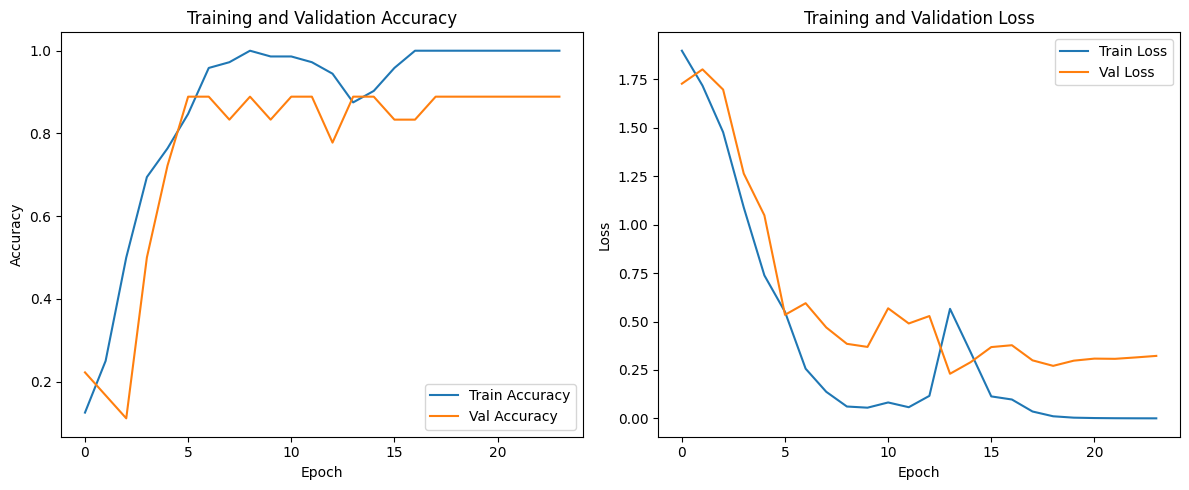

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Task 5: Evaluate on test set

In [14]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6000 - loss: 0.8925
Test Loss: 0.8924773931503296
Test Accuracy: 0.6000000238418579


# Task 6: Save and load the model

In [15]:
model.save("fruit_classifier_model.h5")
print("Model saved successfully.")

Model saved successfully.


In [16]:
loaded_model = keras.models.load_model("fruit_classifier_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6000 - loss: 0.8925
Loaded Model Test Loss: 0.8924773931503296
Loaded Model Test Accuracy: 0.6000000238418579


# Task 7: Predictions and classification report

In [17]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       1.00      0.80      0.89         5
     cupuacu       0.67      0.40      0.50         5
    graviola       0.45      1.00      0.62         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.29      0.40      0.33         5

    accuracy                           0.60        30
   macro avg       0.73      0.60      0.59        30
weighted avg       0.73      0.60      0.59        30

